# AI-Based Children's Mood Analysis Pipeline

This notebook consolidates the entire configuration, dataset utilities, model architecture, training loop, and inline inference of the emotion detection system. It employs **YOLO11 face detection model** for face detection and a fine-tuned **EfficientNetV2-S** (via `timm`) for expression classification.

In [1]:
import os
import sys
import time
import glob
import urllib.request
import logging
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
import timm

# Check device availability
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

device = get_device()
print(f"Using device: {device}")

Using device: mps


/Users/parthiban/Projects/n8n/mood-detection/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

We define the `Config` class, referencing paths relative to the current working directory (`os.getcwd()`).

In [2]:
class Config:
    # --- Dataset Configuration ---
    CLASSES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    NUM_CLASSES = len(CLASSES)
    
    # Paths (using current working directory for notebook environment)
    BASE_DIR = os.getcwd()
    DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
    TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
    # Use 'val' if it exists, otherwise fall back to 'test'
    VAL_DIR = os.path.join(DATASET_DIR, 'val') if os.path.exists(os.path.join(DATASET_DIR, 'val')) else os.path.join(DATASET_DIR, 'test')
    
    OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_model.pth')
    PLOT_PATH = os.path.join(OUTPUT_DIR, 'training_curves.png')
    LOG_PATH = os.path.join(OUTPUT_DIR, 'training.log')
    
    # YOLO Face detection model path (weights downloaded if not present)
    YOLO_FACE_MODEL = os.path.join(BASE_DIR, 'yolo11n-face.pt')
    YOLO_FACE_HF_REPO = "AdamCodd/YOLOv11n-face-detection"
    YOLO_FACE_HF_FILE = "model.pt"
    
    # --- Model Configuration ---
    MODEL_NAME = 'tf_efficientnetv2_s.in21k_ft_in1k'
    IMAGE_SIZE = 224
    
    # ImageNet normalization statistics
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]
    
    # --- Training Hyperparameters ---
    BATCH_SIZE = 32
    EPOCHS = 5  # Reduced epochs for quick run in notebook; standard is 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-2
    
    # Early Stopping
    EARLY_STOPPING_PATIENCE = 7
    
    # Scheduler (ReduceLROnPlateau)
    SCHEDULER_FACTOR = 0.5
    SCHEDULER_PATIENCE = 2
    SCHEDULER_MIN_LR = 1e-6

# Ensure directories exist
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
print("Base configuration loaded and outputs directory verified.")

Base configuration loaded and outputs directory verified.


## Custom Dataset Loader & Transforms

Here we define the PyTorch dataset helper `EmotionDataset` and the augmentations/loaders.

In [3]:
class EmotionDataset(Dataset):
    """
    Custom Dataset for loading emotion images from structured directory.
    Uses the exact class order defined in Config.CLASSES to prevent
    alphabetical mismatch bugs.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Dataset directory not found: {root_dir}")
            
        for class_idx, class_name in enumerate(Config.CLASSES):
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.exists(class_folder):
                alternative_folders = [d for d in os.listdir(root_dir) if d.lower() == class_name.lower()]
                if alternative_folders:
                    class_folder = os.path.join(root_dir, alternative_folders[0])
                else:
                    print(f"Warning: Class folder '{class_name}' not found under {root_dir}")
                    continue
            
            pattern = os.path.join(class_folder, "*.*")
            file_paths = glob.glob(pattern)
            valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
            
            for path in file_paths:
                _, ext = os.path.splitext(path.lower())
                if ext in valid_extensions:
                    self.samples.append((path, class_idx))
                    
        if len(self.samples) == 0:
            print(f"Warning: No valid images found in dataset directory {root_dir}")
            
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new('RGB', (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

def get_transforms():
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(Config.IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=Config.NORM_MEAN, std=Config.NORM_STD)
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(Config.IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=Config.NORM_MEAN, std=Config.NORM_STD)
    ])
    
    return train_transform, val_transform

def get_dataloaders(train_dir, val_dir, batch_size):
    train_transform, val_transform = get_transforms()
    
    train_dataset = EmotionDataset(train_dir, transform=train_transform)
    val_dataset = EmotionDataset(val_dir, transform=val_transform)
    
    print(f"Train Dataset size: {len(train_dataset)} images")
    print(f"Validation Dataset size: {len(val_dataset)} images")
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )
    
    return train_loader, val_loader

## Model Architecture

The `EmotionClassifier` defines the custom EfficientNetV2-S model structure.

In [4]:
class EmotionClassifier(nn.Module):
    def __init__(self, num_classes=Config.NUM_CLASSES, pretrained=True):
        super(EmotionClassifier, self).__init__()
        print(f"Loading pretrained backbone: {Config.MODEL_NAME}...")
        self.backbone = timm.create_model(
            Config.MODEL_NAME, 
            pretrained=pretrained,
            num_classes=num_classes
        )
        
        if hasattr(self.backbone, 'classifier'):
            in_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Linear(in_features, num_classes)
        elif hasattr(self.backbone, 'head') and hasattr(self.backbone.head, 'fc'):
            in_features = self.backbone.head.fc.in_features
            self.backbone.head.fc = nn.Linear(in_features, num_classes)
        elif hasattr(self.backbone, 'fc'):
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(in_features, num_classes)
        else:
            raise AttributeError("Unable to locate model classification layer in backbone.")
            
        print(f"Model initialized. Classifier output dimension set to {num_classes} classes.")

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        print("Freezing backbone layers...")
        for name, param in self.backbone.named_parameters():
            if 'classifier' not in name and 'head' not in name and 'fc' not in name:
                param.requires_grad = False

    def unfreeze_backbone(self):
        print("Unfreezing backbone layers...")
        for param in self.backbone.parameters():
            param.requires_grad = True

## Training Utilities & Helpers

Here we define metric plotting, early stopping logic, weights downloading, and synthetic dataset generation helper functions.

In [5]:
class EarlyStopping:
    def __init__(self, patience=Config.EARLY_STOPPING_PATIENCE, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def download_file(url, destination):
    print(f"Downloading {url} to {destination}...")
    class DownloadProgressBar(tqdm):
        def update_to(self, b=1, bsize=1, tsize=None):
            if tsize is not None:
                self.total = tsize
            self.update(b * bsize - self.n)
            
    os.makedirs(os.path.dirname(destination), exist_ok=True)
    try:
        with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=os.path.basename(destination)) as t:
            urllib.request.urlretrieve(url, filename=destination, reporthook=t.update_to)
        print(f"Successfully downloaded: {destination}")
    except Exception as e:
        print(f"Failed to download: {e}")
        raise e

def ensure_yolo_face_model():
    model_path = Config.YOLO_FACE_MODEL
    if not os.path.exists(model_path):
        print(f"YOLO Face detection model not found at {model_path}.")
        print("Downloading YOLO11 Face detection model from Hugging Face...")
        from huggingface_hub import hf_hub_download
        import shutil
        downloaded_path = hf_hub_download(repo_id=Config.YOLO_FACE_HF_REPO, filename=Config.YOLO_FACE_HF_FILE)
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        shutil.copy(downloaded_path, model_path)
        print(f"Successfully downloaded and copied model to: {model_path}")
    else:
        print(f"YOLO Face detection model exists at {model_path}.")
    return model_path

def create_dummy_dataset():
    print("Dataset directory empty or missing. Generating synthetic dummy images for verification...")
    for split in ['train', 'val']:
        split_dir = os.path.join(Config.DATASET_DIR, split)
        num_images_per_class = 16 if split == 'train' else 8
        
        for emotion in Config.CLASSES:
            class_dir = os.path.join(split_dir, emotion)
            os.makedirs(class_dir, exist_ok=True)
            
            for i in range(num_images_per_class):
                img_path = os.path.join(class_dir, f"synthetic_{i}.jpg")
                if not os.path.exists(img_path):
                    random_data = np.random.randint(0, 256, (Config.IMAGE_SIZE, Config.IMAGE_SIZE, 3), dtype=np.uint8)
                    img = Image.fromarray(random_data)
                    img.save(img_path)
    print(f"Synthetic dummy dataset generated successfully at: {Config.DATASET_DIR}")

def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-s', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
    plt.plot(epochs, val_accs, 'r-s', label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

## Training & Validation Runners

Functions to run standard train and validation epochs.

In [6]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="Training Batches", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        current_loss = running_loss / total
        current_acc = 100.0 * correct / total
        pbar.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.2f}%")
        
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Execution: Model Training

We load data, instantiate the network, and run the training cycle.

Train Dataset size: 28709 images
Validation Dataset size: 7178 images
Loading pretrained backbone: tf_efficientnetv2_s.in21k_ft_in1k...
Model initialized. Classifier output dimension set to 7 classes.
Starting training loop...
--- Epoch 1/5 | LR: 0.000100 ---


Training Batches:   0%|          | 0/898 [00:00<?, ?it/s]/Users/parthiban/Projects/n8n/mood-detection/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 Summary: Train Loss: 1.1850 | Train Acc: 55.43% | Val Loss: 0.9842 | Val Acc: 63.79%
Saved new best checkpoint to /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/outputs/best_model.pth with Val Accuracy: 63.79%
--- Epoch 2/5 | LR: 0.000100 ---


Epoch 02 Summary: Train Loss: 0.9025 | Train Acc: 66.44% | Val Loss: 0.8982 | Val Acc: 66.17%
Saved new best checkpoint to /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/outputs/best_model.pth with Val Accuracy: 66.17%
--- Epoch 3/5 | LR: 0.000100 ---


Epoch 03 Summary: Train Loss: 0.7691 | Train Acc: 71.54% | Val Loss: 0.8672 | Val Acc: 68.51%
Saved new best checkpoint to /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/outputs/best_model.pth with Val Accuracy: 68.51%
--- Epoch 4/5 | LR: 0.000100 ---


Epoch 04 Summary: Train Loss: 0.6499 | Train Acc: 76.23% | Val Loss: 0.8837 | Val Acc: 68.90%
Saved new best checkpoint to /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/outputs/best_model.pth with Val Accuracy: 68.90%
--- Epoch 5/5 | LR: 0.000100 ---


Epoch 05 Summary: Train Loss: 0.5374 | Train Acc: 80.37% | Val Loss: 0.9305 | Val Acc: 68.61%
Training process finished.


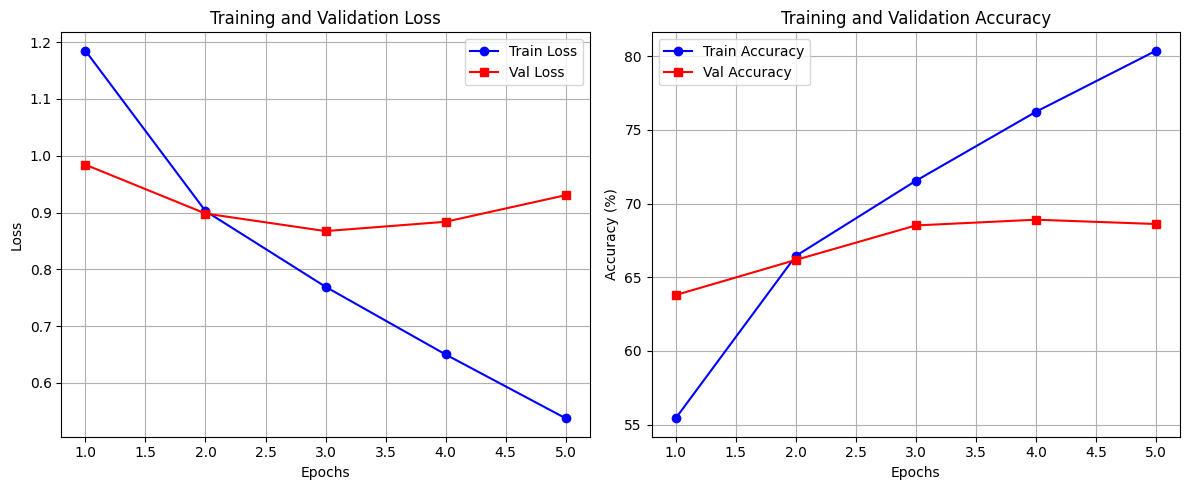

In [7]:
# Verify dataset directories exist & are populated
dataset_empty = True
if os.path.exists(Config.DATASET_DIR):
    for root, dirs, files in os.walk(Config.DATASET_DIR):
        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
            dataset_empty = False
            break
            
if dataset_empty:
    create_dummy_dataset()

# Create dataloaders
train_loader, val_loader = get_dataloaders(Config.TRAIN_DIR, Config.VAL_DIR, batch_size=Config.BATCH_SIZE)

# Initialize Model
model = EmotionClassifier(num_classes=Config.NUM_CLASSES, pretrained=True)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=Config.SCHEDULER_FACTOR, patience=Config.SCHEDULER_PATIENCE, min_lr=Config.SCHEDULER_MIN_LR)
early_stopping = EarlyStopping(patience=Config.EARLY_STOPPING_PATIENCE)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

print("Starting training loop...")
for epoch in range(1, Config.EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"--- Epoch {epoch}/{Config.EPOCHS} | LR: {current_lr:.6f} ---")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d} Summary: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs(os.path.dirname(Config.BEST_MODEL_PATH), exist_ok=True)
        torch.save(model.state_dict(), Config.BEST_MODEL_PATH)
        print(f"Saved new best checkpoint to {Config.BEST_MODEL_PATH} with Val Accuracy: {val_acc:.2f}%")
        
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"Early stopping triggered! Training stopped after epoch {epoch}.")
        break

print("Training process finished.")
plot_metrics(train_losses, val_losses, train_accs, val_accs)

## Inline Inference Demo & Visualization

Rather than popping up OpenCV window streams, we implement an inline image inference helper. It performs YOLO face detection and Emotion Classification, plotting results inline with bounding boxes and color overlays.

In [8]:
import cv2

# RGB style colors mapped to emotion categories
EMOTION_COLORS = {
    'Happy': (255, 242, 0),       # RGB Yellow
    'Sad': (0, 131, 235),        # RGB Sky Blue
    'Angry': (240, 20, 46),      # RGB Crimson Red
    'Fear': (130, 50, 180),      # RGB Violet-Purple
    'Surprise': (255, 120, 0),    # RGB Vibrant Orange
    'Disgust': (60, 180, 60),     # RGB Forrest Green
    'Neutral': (200, 200, 200)    # RGB Soft Gray
}

def predict_and_visualize(image_path, weights_path=Config.BEST_MODEL_PATH):
    """
    Runs face detection and emotion classification on a static image,
    and displays the result inline using matplotlib.
    """
    if not os.path.exists(image_path):
        print(f"Image not found at: {image_path}")
        return
        
    # Ensure YOLO Face weights are downloaded
    yolo_weights_path = ensure_yolo_face_model()
    print("Loading YOLO Face Detector...")
    face_detector = YOLO(yolo_weights_path)
    
    # Load Emotion Classifier
    print("Loading Emotion Classifier...")
    classifier = EmotionClassifier(num_classes=Config.NUM_CLASSES, pretrained=True)
    if os.path.exists(weights_path):
        state_dict = torch.load(weights_path, map_location=device)
        if 'model_state_dict' in state_dict:
            classifier.load_state_dict(state_dict['model_state_dict'])
        else:
            classifier.load_state_dict(state_dict)
        print("Trained weights loaded successfully.")
    else:
        print("WARNING: Trained weights not found. Using pretrained ImageNet feature extraction fallback.")
        
    classifier = classifier.to(device)
    classifier.eval()
    
    # Validation transforms
    _, val_transform = get_transforms()
    
    # Load image using OpenCV and convert to RGB
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image from {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Face detection
    results = face_detector(img_rgb, conf=0.4, verbose=False)
    h, w, _ = img.shape
    faces_detected = 0
    
    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)
            
            face_crop = img_rgb[y1:y2, x1:x2]
            if face_crop.size == 0:
                continue
                
            faces_detected += 1
            
            try:
                face_pil = Image.fromarray(face_crop)
                face_tensor = val_transform(face_pil).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    logits = classifier(face_tensor)
                    probabilities = torch.softmax(logits, dim=1)[0]
                    max_prob, pred_idx = torch.max(probabilities, dim=0)
                    
                    emotion_label = Config.CLASSES[pred_idx.item()]
                    confidence = max_prob.item() * 100.0
                    
                color = EMOTION_COLORS.get(emotion_label, (255, 255, 255))
                
                # Bounding box
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 4)
                
                # Label text
                label_text = f"{emotion_label}: {confidence:.1f}%"
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.8
                thickness = 2
                
                (text_w, text_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)
                rect_y1 = max(0, y1 - text_h - 10)
                rect_y2 = y1 if y1 - text_h - 10 >= 0 else y1 + text_h + 10
                
                cv2.rectangle(img_rgb, (x1, rect_y1), (x1 + text_w + 10, rect_y2), color, -1)
                cv2.putText(img_rgb, label_text, (x1 + 5, rect_y2 - 5 if y1 - text_h - 10 >= 0 else rect_y2 - 7),
                            font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
            except Exception as e:
                print(f"Error processing detected face: {e}")
                
    print(f"Detection done. Total faces detected: {faces_detected}")
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Inference Results: {faces_detected} face(s) found")
    plt.show()

### Test Visual Inference

Let's grab a synthetic validation image and verify that the inline visual detector works.

Testing visual inference on: /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/dataset/test/happy/PrivateTest_45699463.jpg
YOLO Face detection model exists at /Users/parthiban/Projects/n8n/mood-detection/emotion_ai/yolo11n-face.pt.
Loading YOLO Face Detector...
Loading Emotion Classifier...
Loading pretrained backbone: tf_efficientnetv2_s.in21k_ft_in1k...


Model initialized. Classifier output dimension set to 7 classes.
Trained weights loaded successfully.
Detection done. Total faces detected: 0


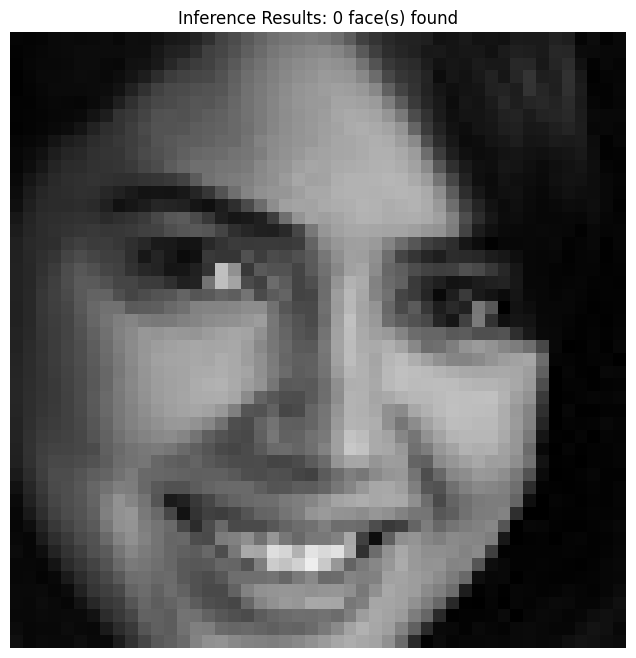

In [9]:
# Find a synthetic validation image to test prediction
synthetic_images = glob.glob(os.path.join(Config.VAL_DIR, "*", "*.jpg"))
if synthetic_images:
    test_img_path = synthetic_images[0]
    print(f"Testing visual inference on: {test_img_path}")
    predict_and_visualize(test_img_path)
else:
    print("No images found to run test inference on.")